In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [3]:
df = sns.load_dataset("iris")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [5]:
X = df.drop('species', axis=1)
y = df['species']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [7]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


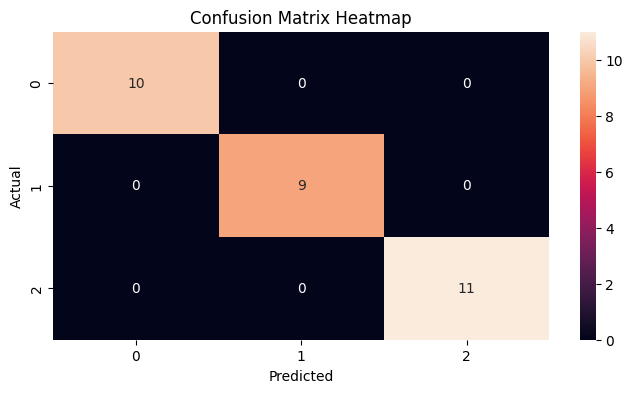

In [8]:
# confusion matrix heatmap
plt.figure(figsize=(8,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()


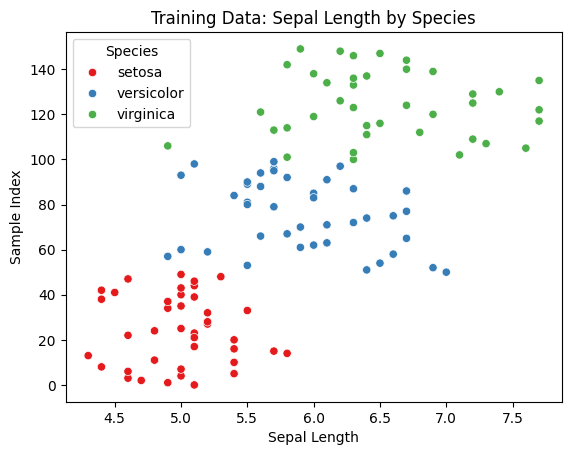

In [11]:
# plot the datasets using 'sepal_length' as the feature
# plot the training dataset using 'sepal_length' and color by species
sns.scatterplot(x=X_train['sepal_length'], y=X_train.index, hue=y_train, palette='Set1')
plt.xlabel('Sepal Length')
plt.ylabel('Sample Index')
plt.title('Training Data: Sepal Length by Species')
plt.legend(title='Species')
plt.show()

SVR

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = sns.load_dataset("diamonds")
df = df.sample(frac=0.1, random_state=42)  # downsample for performance


X = df.drop('price', axis=1)
y = df['price']

# convert categorical into numeric
label_Encoder = {}
for col in X.select_dtypes(include='category').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_Encoder[col] = le

In [ ]:
# split test train 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standarize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)



svr_model = SVR()
svr_model.fit(X_train, y_train)

y_pred = svr_model.predict(X_test)


# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

r2 = r2_score(y_test, y_pred)
print(f"R^2 Score: {r2}")

mae = mean_absolute_error(y_test, y_preds)
print(f"Mean Absolute Error: {mae}")


Mean Squared Error: 15478613.658540443
R^2 Score: -0.0004830328448832688
Mean Absolute Error: 2374.2097162406344
